# Store Sales Forecast
### A 16-day demand forecast for 1,782 store–product combinations

**What this is.** A daily sales forecast for the two weeks following 15 August 2017, covering
every combination of **54 stores** and **33 product categories** at a large Ecuadorian grocery
chain. The goal is the classic retail balancing act: order too much of something and it goes
to waste (or sits as dead stock); order too little and shelves go empty while customers walk
out empty-handed.

**The result.** Tested against a held-out two-week period the models did not see during
training, the forecast is **roughly 26% more accurate** than the simplest reasonable
alternative — assuming each day looks like the same weekday over the past two months. The full
comparison is in *Testing the Model*, below.

**Four changes since the previous version of this report**, each explained where it appears:

- **The forecast is produced by four models rather than one**, because a forecast for tomorrow
  and a forecast for two weeks out are not the same problem — see *Teaching the Model What
  Matters*.
- **Product lines that have stopped selling are forecast as exactly zero** rather than as a
  small positive trickle — see *Products That No Longer Sell*.
- **A second, differently-built forecaster now contributes to every number** — 30% for most
  categories — because the two make opposite mistakes and averaging them beats either alone —
  see *A Second Opinion*.
- **Three categories use a different mix of the two forecasters**, found by testing what works
  across several past years rather than the current forecast alone — see *A Second Opinion*.

**How to read this notebook.** Code cells do the work; the charts and the text around them
tell the story. Anyone who wants to skip the mechanics can read the section headings and
figures alone and still come away with the key findings.

| Section | What it covers |
|---|---|
| What Drives Sales | The patterns in the historical data the forecast is built on |
| Building a Clean History | Two data-quality fixes applied before any modelling |
| The Holiday Calendar | How Ecuador's public holidays are represented |
| Teaching the Model What Matters | The signals the model is given, and why there are four models |
| Products That No Longer Sell | Why dead product lines need explicit handling |
| A Second Opinion | A differently-built forecaster, and why averaging helps |
| Testing the Model | How accurate the forecast is, and where it is weaker |
| The 16-Day Forecast | The headline numbers |
| Where to Pay Extra Attention | Specific risks worth a human look |

---
## Setup

In [1]:
import gc, time, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

# --- Chart styling: a fixed-order categorical palette, a single-hue ramp for magnitude,
# and a shared "finish" helper, so every chart in this notebook reads as one system. ---
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
from matplotlib.colors import LinearSegmentedColormap
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SURFACE, INK, SECOND, MUTED = "#ffffff", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS_LINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.edgecolor": AXIS_LINE, "axes.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.labelcolor": SECOND, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "lines.linewidth": 2, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": plt.cycler(color=CAT),
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    if title:
        ax.set_title(title, loc="left", pad=24 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=8.5,
                va="bottom", ha="left")
    ax.set_xlabel(xlabel or ""); ax.set_ylabel(ylabel or "")
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

def thousands(x, _=None):
    for div, suf in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(x) >= div:
            return f"{x/div:,.1f}{suf}".replace(".0", "")
    return f"{x:,.0f}"

# --- Data location: works whether this runs on Kaggle or locally. ---
COMP = "store-sales-time-series-forecasting"
REQUIRED = {"train.csv", "test.csv", "stores.csv", "holidays_events.csv"}

def has_data(p: Path) -> bool:
    try:
        return p.is_dir() and REQUIRED.issubset({f.name for f in p.iterdir() if f.is_file()})
    except OSError:
        return False

def find_data() -> Path:
    root = Path("/kaggle/input")
    if root.is_dir():
        for cand in [root / COMP, *sorted(d for d in root.iterdir() if d.is_dir())]:
            if has_data(cand):
                return cand
    for cand in (Path("data"), Path("../data"), Path("../../data")):
        if has_data(cand):
            return cand
    try:
        import kagglehub
        got = Path(kagglehub.competition_download(COMP))
        if has_data(got):
            return got
        for sub in got.rglob("*"):
            if has_data(sub):
                return sub
    except Exception as exc:
        print(f"kagglehub download failed: {exc}")
    raise FileNotFoundError(f"Could not find {sorted(REQUIRED)}. Put the CSVs in ./data.")

DATA = find_data()
ON_KAGGLE = Path("/kaggle/working").is_dir()
# On Kaggle this must be /kaggle/working so the "Submit to Competition" flow can find
# submission.csv. Locally it goes in its own subfolder rather than the shared submissions/
# folder, so running this report can never overwrite the primary notebook's own output.
OUT = Path("/kaggle/working") if ON_KAGGLE else Path("submissions/stakeholder")
OUT.mkdir(parents=True, exist_ok=True)

HORIZON = 16
MODEL_START = pd.Timestamp("2015-01-01")
EQ_START, EQ_END = pd.Timestamp("2016-04-16"), pd.Timestamp("2016-04-22")
DORMANT_DAYS = 365

DTYPES = {"store_nbr": "int8", "family": "category", "onpromotion": "int32", "sales": "float32"}
train  = pd.read_csv(DATA / "train.csv", parse_dates=["date"], dtype=DTYPES)
test   = pd.read_csv(DATA / "test.csv",  parse_dates=["date"], dtype=DTYPES)
stores = pd.read_csv(DATA / "stores.csv", dtype={"store_nbr": "int8"})
hol    = pd.read_csv(DATA / "holidays_events.csv", parse_dates=["date"])

TRAIN_END   = train.date.max()
VALID_START = TRAIN_END - pd.Timedelta(days=HORIZON - 1)

print(f"history available : {train.date.min():%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}  "
      f"({train.date.nunique():,} days)")
print(f"forecasting        : {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}  "
      f"(16 days)")
print(f"scope               : {train.store_nbr.nunique()} stores x {train.family.nunique()} "
      f"product categories = {train.store_nbr.nunique()*train.family.nunique():,} forecasts/day")

history available : 2013-01-01 -> 2017-08-15  (1,684 days)
forecasting        : 2017-08-16 -> 2017-08-31  (16 days)


scope               : 54 stores x 33 product categories = 1,782 forecasts/day


---
## What Drives Sales

Two patterns from the historical data shape the forecast more than anything else: **which
day of the week it is**, and **whether items are on promotion**.

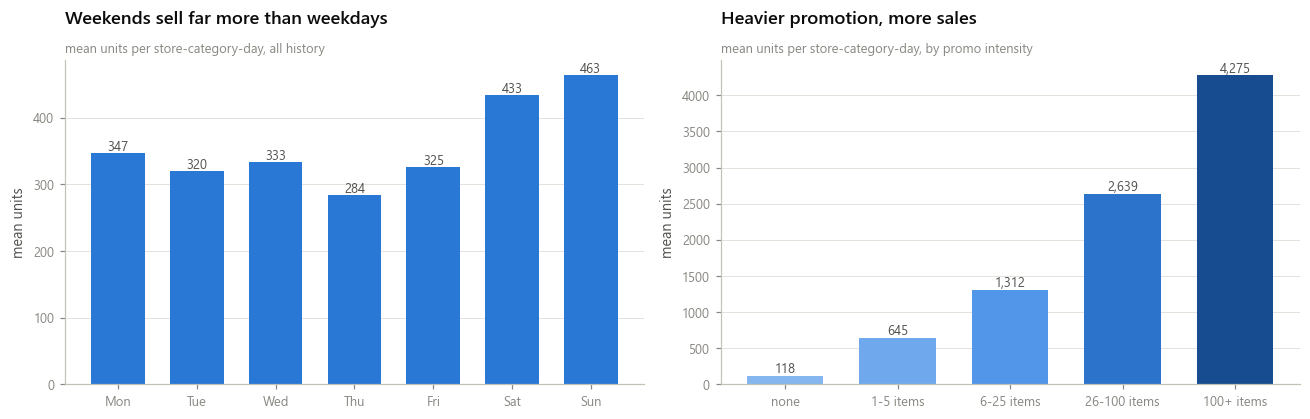

weekend uplift: Sunday sells +63% more than Thursday, the weekly low
promo uplift  : the heaviest-promoted rows sell 36x more than unpromoted rows


In [2]:
dow = train.groupby(train.date.dt.dayofweek).sales.mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

promo_hist = train[train.date >= "2014-04-01"].copy()   # promo tracking starts 2014-04-01
bins = [-1, 0, 5, 25, 100, 100_000]
labels = ["none", "1-5 items", "6-25 items", "26-100 items", "100+ items"]
promo_hist["bucket"] = pd.cut(promo_hist.onpromotion, bins=bins, labels=labels)
promo_mean = promo_hist.groupby("bucket", observed=True).sales.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))

bars = axes[0].bar(names, dow.values, color=CAT[0], width=0.68)
for b, v in zip(bars, dow.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom",
                fontsize=8.5, color=SECOND)
finish(axes[0], "Weekends sell far more than weekdays",
       "mean units per store-category-day, all history", ylabel="mean units")

norm = (promo_mean - promo_mean.min()) / (promo_mean.max() - promo_mean.min())
b2 = axes[1].bar(promo_mean.index.astype(str), promo_mean.values,
                 color=SEQ(0.25 + 0.6 * norm.values), width=0.68)
for b, v in zip(b2, promo_mean.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom",
                fontsize=8.5, color=SECOND)
finish(axes[1], "Heavier promotion, more sales",
       "mean units per store-category-day, by promo intensity", ylabel="mean units")

fig.tight_layout(); plt.show()

print(f"weekend uplift: Sunday sells {dow[6]/dow[3]-1:+.0%} more than Thursday, the weekly low")
print(f"promo uplift  : the heaviest-promoted rows sell "
      f"{promo_mean.iloc[-1]/promo_mean.iloc[0]:.0f}x more than unpromoted rows")

### What does *not* drive sales: the oil price

Ecuador is an oil-exporting economy, so it is reasonable to expect fuel prices to move
consumer spending — and this is one of the first questions people ask of this dataset. It was
checked carefully, and the answer is that **there is no usable relationship**.

The chart below shows 2016, the year with the largest oil move in the whole dataset: crude
runs from **$26 to $54, a 45% rise**, while daily sales stay flat around 700–900k units. The
visible peaks in sales are explained by other things entirely — the April earthquake and the
December holidays — not by oil.

The two series are shown in **separate panels sharing a time axis, deliberately**. Drawing
them on one chart with two different y-axes would let any two trending lines look related,
which is exactly the trap here: measured on raw levels across the full history, oil and sales
show a strong-looking **−0.63** correlation. That number is an artefact of both series
drifting over four and a half years. Once the trend is removed by comparing *changes* rather
than *levels*, it collapses to about **−0.02** — no relationship. Tested again as a lagged
effect (does expensive oil depress sales one, two or three weeks later?), every lag also came
back at essentially zero.

Oil is therefore **not used as an input to the forecast**. It was also tested the harder way —
by adding it to the model and submitting the result for real evaluation — and the forecast
came back measurably worse. Four independent checks, one conclusion.

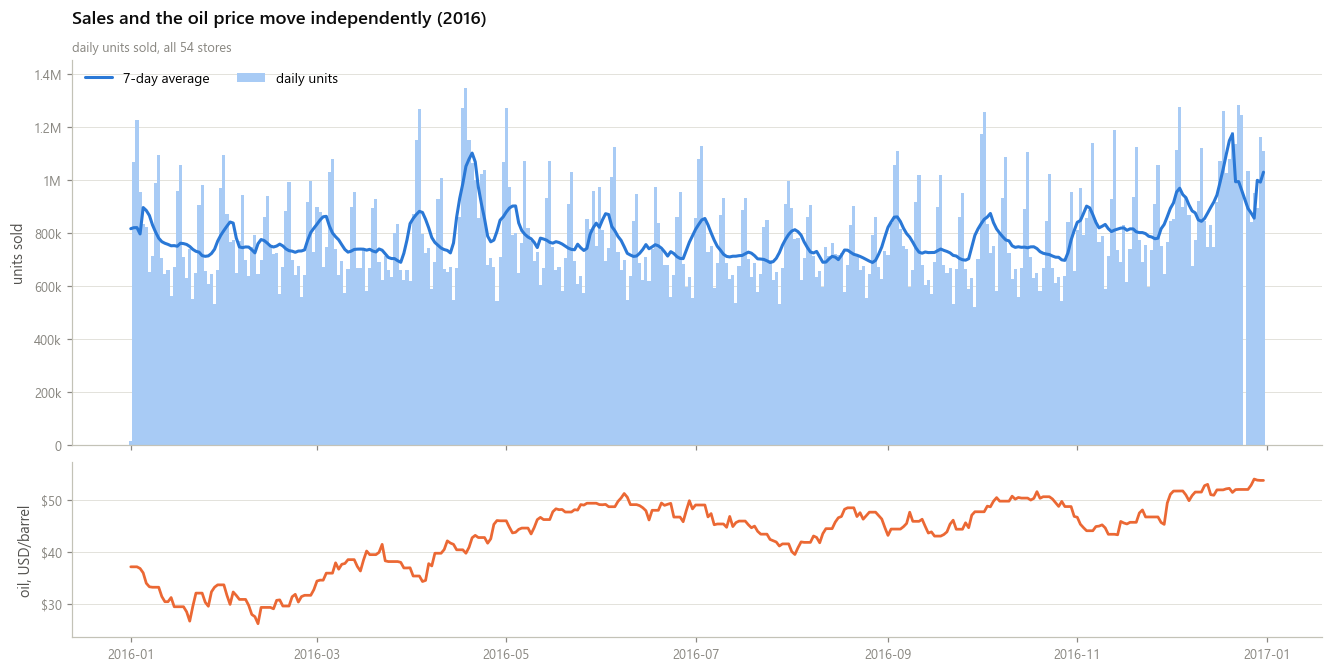

2016: oil $26 -> $54 (+45% across the year), sales flat at 788,674 units/day on average
correlation, week-over-week changes: -0.063 -- no usable relationship, which is why oil is not an input to the forecast


In [3]:
oil = pd.read_csv(DATA / "oil.csv", parse_dates=["date"])

YEAR = 2016
days = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31", freq="D")

# 25 Dec is absent from train.csv (every store shut); 0 is the true value, the same treatment
# applied before any lag feature is built.
daily_units = train.groupby("date").sales.sum().reindex(days).fillna(0.0)
# Oil does not trade at weekends or market holidays, so carry the last close forward.
oil_daily = (oil.set_index("date").dcoilwtico
             .reindex(pd.date_range(oil.date.min(), oil.date.max(), freq="D"))
             .ffill().reindex(days))

fig, (ax_s, ax_o) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                 height_ratios=[2.2, 1], constrained_layout=True)

ax_s.bar(daily_units.index, daily_units.values, color="#a8cbf5", width=1.0, linewidth=0,
         label="daily units")
# 366 daily bars are dominated by the weekly cycle; the 7-day average is the line actually
# comparable with the oil price below.
ax_s.plot(daily_units.index, daily_units.rolling(7, center=True, min_periods=4).mean(),
          color=CAT[0], lw=2, label="7-day average")
ax_s.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
ax_s.set_ylim(0, daily_units.max() * 1.08)
ax_s.legend(loc="upper left", ncol=2)
finish(ax_s, f"Sales and the oil price move independently ({YEAR})",
       "daily units sold, all 54 stores", ylabel="units sold")

ax_o.plot(oil_daily.index, oil_daily.values, color=CAT[1], lw=1.8)
ax_o.set_ylim(oil_daily.min() * 0.9, oil_daily.max() * 1.06)
ax_o.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
finish(ax_o, None, None, ylabel="oil, USD/barrel")

plt.show()

chg_oil = oil_daily.diff(7)
chg_sales = daily_units.diff(7)
ok = chg_oil.notna() & chg_sales.notna()
print(f"{YEAR}: oil ${oil_daily.min():,.0f} -> ${oil_daily.max():,.0f} "
      f"({oil_daily.iloc[-1]/oil_daily.iloc[0]-1:+.0%} across the year), "
      f"sales flat at {daily_units.mean():,.0f} units/day on average")
print(f"correlation, week-over-week changes: {np.corrcoef(chg_oil[ok], chg_sales[ok])[0,1]:+.3f} "
      f"-- no usable relationship, which is why oil is not an input to the forecast")

---
## Building a Clean History

Two corrections are applied to the raw sales history before any forecasting begins, because
leaving either uncorrected would quietly bias the model.

**Missing Christmas Days.** Every store closes on 25 December, and those days are simply
absent from the data rather than recorded as zero. Left as gaps, they silently distort any
calculation of "sales over the last N weeks." They are added back in as zero-sales days,
which is what actually happened.

**The April 2016 earthquake.** A magnitude-7.8 earthquake struck Ecuador on 2016-04-16,
triggering a week of relief-buying that does not reflect normal demand. If left in the
history untouched, the model could learn to expect a repeat of that spike — which is not
useful, since nothing like it is expected in the forecast period. That week is replaced with
each product's typical sales for that day of the week, based on the surrounding two months.

The second fix matters more than it looks. The shock does not only distort the week it
happened: every "average of the last N weeks" calculation that reaches back into it carries
the spike forward for months. Correcting the history at source fixes all of them at once.

In [4]:
t0 = time.time()
full_idx = pd.date_range(train.date.min(), test.date.max(), freq="D")

both = pd.concat([train.drop(columns="sales"), test], ignore_index=True)
both["family"] = both.family.astype(str)

sales_w = (train.assign(family=train.family.astype(str))
           .pivot(index="date", columns=["store_nbr", "family"], values="sales")
           .reindex(full_idx).sort_index(axis=1))
promo_w = (both.pivot(index="date", columns=["store_nbr", "family"], values="onpromotion")
           .reindex(full_idx).sort_index(axis=1).fillna(0.0))

xmas = pd.DatetimeIndex([d for d in full_idx
                         if d <= TRAIN_END and d not in set(train.date.unique())])
sales_w.loc[xmas] = 0.0

assert (sales_w.columns == promo_w.columns).all()
assert sales_w.loc[:TRAIN_END].isna().sum().sum() == 0, "no gaps may remain in the train span"

SERIES = sales_w.columns
n_s = len(SERIES)
print(f"Christmas days restored as zero-sales: {[f'{d:%Y-%m-%d}' for d in xmas]}")

Christmas days restored as zero-sales: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


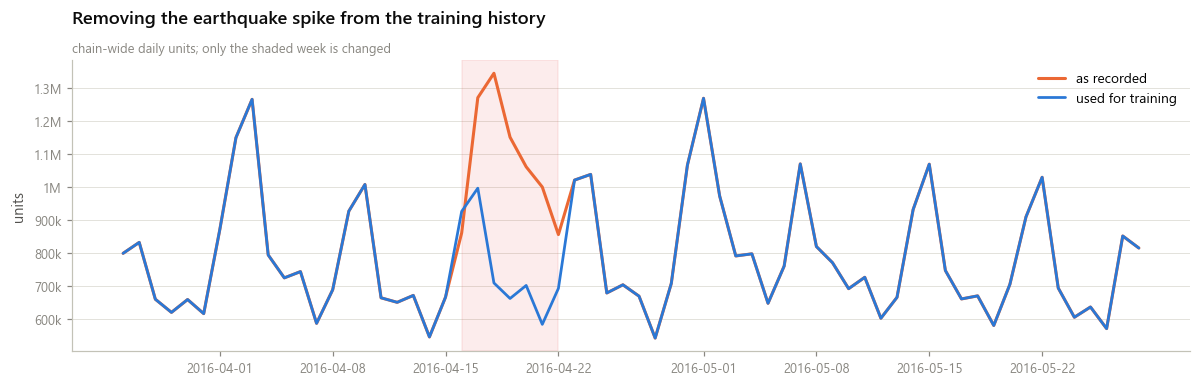

In [5]:
eq_dates = pd.date_range(EQ_START, EQ_END)
raw_tot = sales_w.sum(axis=1)                            # chain-wide total, BEFORE the fix

def repair_window(W, start, end, halo_weeks=8):
    out = W.copy()
    win = pd.date_range(start, end)
    ctx = W.loc[start - pd.Timedelta(weeks=halo_weeks): end + pd.Timedelta(weeks=halo_weeks)]
    ctx = ctx.drop(index=win, errors="ignore")
    by_dow = ctx.groupby(ctx.index.dayofweek).median()
    for d in win:
        out.loc[d] = by_dow.loc[d.dayofweek].values
    return out

sales_w = repair_window(sales_w, EQ_START, EQ_END)
cln_tot = sales_w.sum(axis=1)                             # chain-wide total, AFTER the fix

fig, ax = plt.subplots(figsize=(11, 3.6))
lo, hi = EQ_START - pd.Timedelta(days=21), EQ_START + pd.Timedelta(days=42)
ax.plot(raw_tot.loc[lo:hi].index, raw_tot.loc[lo:hi].values, color=CAT[1], label="as recorded")
ax.plot(cln_tot.loc[lo:hi].index, cln_tot.loc[lo:hi].values, color=CAT[0], lw=1.8,
       label="used for training")
ax.axvspan(EQ_START, EQ_END, color=CAT[7], alpha=0.10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Removing the earthquake spike from the training history",
      "chain-wide daily units; only the shaded week is changed", ylabel="units")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

---
## The Holiday Calendar

Ecuador's public holidays have a few quirks worth knowing about, because getting them wrong
would mislead the model about which days are actually holidays:

- A holiday that is **officially transferred** to a different date is treated as a normal day
  on its original date — the *new* date is the one that counts.
- **"Bridge" days** extend a holiday into a long weekend, and are often paid back later with
  an extra **"work day"** on what would normally be a day off.
- Holidays are either **national** (every store), **local** (one city only), or **regional**
  (a handful of provinces) — each is matched to the right stores individually.

One detail matters more than it sounds: not all holidays affect sales the same way. New
Year's Day, when every store is shut, and a long-weekend "bridge" day, when people are out
shopping, are opposite effects — so each holiday is identified individually rather than
lumped into a single "is it a holiday" flag.

In [6]:
h = hol.copy()
h = h[~((h.type == "Holiday") & (h.transferred))]
h.loc[h.type == "Transfer", "type"] = "Holiday"
work_days = set(h.loc[h.type == "Work Day", "date"])
h = h[h.type != "Work Day"]
events = h[h.type == "Event"]
h = h[h.type != "Event"]

nat = pd.DatetimeIndex(sorted(set(h.loc[h.locale == "National", "date"])))
nat_name = (h[h.locale == "National"].drop_duplicates("date")[["date", "description"]]
            .rename(columns={"description": "nat_hol_name"}))
loc_name = (h[h.locale == "Local"].drop_duplicates(["date", "locale_name"])
            [["date", "locale_name", "description"]]
            .rename(columns={"locale_name": "city", "description": "loc_hol_name"}))

geo = stores.set_index("store_nbr")[["city", "state", "type", "cluster"]]
geo.columns = ["city", "state", "store_type", "cluster"]

unmatched_loc = set(loc_name.city) - set(stores.city)
assert not unmatched_loc, f"local holidays not matching any store city: {unmatched_loc}"

pos = np.searchsorted(nat.values, full_idx.values)
prev_d = np.where(pos > 0, (full_idx.values - nat.values[np.maximum(pos - 1, 0)])
                  / np.timedelta64(1, "D"), 999)
next_d = np.where(pos < len(nat), (nat.values[np.minimum(pos, len(nat) - 1)] - full_idx.values)
                  / np.timedelta64(1, "D"), 999)
cal_hol = pd.DataFrame({"date": full_idx,
                        "work_day": full_idx.isin(work_days).astype("int8"),
                        "is_event": full_idx.isin(set(events.date)).astype("int8"),
                        "days_since_nat": np.clip(prev_d, 0, 30).astype("int16"),
                        "days_to_nat": np.clip(next_d, 0, 30).astype("int16")})

print(f"{len(nat_name)} national holiday dates, {len(loc_name)} city-specific holiday dates "
      f"identified over the full history.")

102 national holiday dates, 147 city-specific holiday dates identified over the full history.


---
## Teaching the Model What Matters

The forecast is produced by gradient-boosted tree models (LightGBM) — a technique well suited
to this kind of problem because it can weigh dozens of signals at once and find interactions
between them (for example, "promotions matter more on weekends") without being told to look
for them explicitly.

Each model is given, for every store and product category:

- **Recent sales history** — how much sold recently, and on the same day of the week in
  previous weeks. This turns out to be by far the strongest signal (see *Testing the Model*).
- **Promotions, at three levels of detail** — current and upcoming promotion counts are known
  in advance for the forecast period, so the model can react before a promotion happens, not
  just after. It sees this at the individual store-category level, at the whole-category
  level (has this *category* seen an unusual promotional push, company-wide?), and at the
  whole-chain level (is *today* an unusually promotion-heavy day everywhere?). A campaign run
  across every store for one category, or across every category for one store, is invisible
  to a signal that only looks at a single store-category combination's own history — this is
  what closes that gap.
- **Holidays and paydays** — Ecuador's public sector pays wages on the 15th and the last day
  of the month, which measurably shifts supermarket spending.
- **Store and product identity** — store type, location, and typical product-category
  behaviour, so a new or unusual store can still borrow patterns from similar ones.

### Why there are four models, not one

**A forecast for tomorrow and a forecast for two weeks out are not the same problem.**

Tomorrow's forecast can use yesterday's sales. The forecast for 31 August cannot — at the
moment the forecast is produced, those sales have not happened yet. Every "recent sales"
signal therefore has to be old enough to be genuinely available for the day being predicted.

The previous version of this report used a single model for all sixteen days, which meant
every day was restricted to what the *hardest* day could see: sixteen-day-old sales figures.
The forecast for tomorrow was deliberately ignoring yesterday's sales, even though they were
sitting right there.

Four models now split the horizon, each using the freshest history its own days can legally
rely on:

| Days being forecast | What that model may use |
|---|---|
| Day 1 (16 Aug) | sales up to yesterday |
| Day 2 (17 Aug) | sales up to two days ago |
| Days 3–4 | sales up to four days ago |
| Days 5–16 | sales up to sixteen days ago |

The gain is exactly where the reasoning predicts it: the first few days improve substantially,
and the later days — which were never restricted unnecessarily — are unchanged. *Testing the
Model* shows the breakdown.

In [7]:
L = np.log1p(sales_w).astype("float32")
P = np.log1p(promo_w).astype("float32")
ZERO = (sales_w == 0).astype("float32")

# --- Promotion signals: identical for every model, so built once. -------------------------
# These are exempt from the "must be old enough" rule because promotion schedules are known
# in advance for the whole forecast period -- the chain decides them, so they are not a
# forecast at all.
promo_feats = {}
promo_feats["promo"] = P
promo_feats["promo_rmean_7"] = P.rolling(7, min_periods=1).mean()
promo_feats["promo_rmean_28"] = P.rolling(28, min_periods=3).mean()
promo_feats["promo_lag_16"] = P.shift(HORIZON)
promo_feats["promo_rel_112"] = P - P.rolling(112, min_periods=14).mean()
promo_feats["promo_rel_28"] = P - P.rolling(28, min_periods=5).mean()
for k in (1, 2, 3, 7):
    promo_feats[f"promo_lead_{k}"] = P.shift(-k)
promo_feats["promo_fwd7"] = P.shift(-6).rolling(7, min_periods=1).mean()

chain = P.mean(axis=1)
ones = np.ones(n_s, dtype="float32")
promo_feats["promo_chain_level"] = pd.DataFrame(
    np.outer(chain.to_numpy(dtype="float32"), ones), index=full_idx, columns=SERIES)
promo_feats["promo_chain_rel"] = pd.DataFrame(
    np.outer((chain - chain.rolling(112, min_periods=14).mean()).to_numpy(dtype="float32"),
             ones), index=full_idx, columns=SERIES)
del chain; gc.collect()

promo_raw = np.expm1(P)
fam_plog = np.log1p(promo_raw.T.groupby(level=1).sum().T)
store_plog = np.log1p(promo_raw.T.groupby(level=0).sum().T)
def _bcast(agg, level):
    return agg[SERIES.get_level_values(level)].set_axis(SERIES, axis=1)
promo_feats["fam_promo_rel"] = _bcast(fam_plog - fam_plog.rolling(112, min_periods=14).mean(), 1)
promo_feats["fam_promo_fwd7"] = _bcast(fam_plog.shift(-6).rolling(7, min_periods=1).mean()
                                       - fam_plog.rolling(112, min_periods=14).mean(), 1)
promo_feats["store_promo_rel"] = _bcast(
    store_plog - store_plog.rolling(112, min_periods=14).mean(), 0)
del promo_raw, fam_plog, store_plog; gc.collect()

# "Days since this product last sold anything" -- a running count, computed once and then
# aged appropriately for each model.
A_pos = (sales_w.to_numpy() > 0)
gap = np.empty(A_pos.shape, dtype="float32")
_last = np.full(A_pos.shape[1], -999.0)
for i in range(A_pos.shape[0]):
    gap[i] = i - _last
    _last = np.where(A_pos[i], float(i), _last)
GAP = pd.DataFrame(np.minimum(gap, 999.0), index=sales_w.index, columns=SERIES)
del gap, A_pos; gc.collect()

mask = full_idx >= MODEL_START
dates_sel = full_idx[mask]
LAG_OFFSETS = (0, 1, 2, 3, 4, 5, 6, 12, 19, 33, 47)
print(f"{len(promo_feats)} promotion signals built ({time.time()-t0:.0f}s)")

16 promotion signals built (89s)


In [8]:
def build_design(min_lag):
    # Every "recent sales" signal is aged by at least `min_lag` days, so it is genuinely
    # available on the days this model forecasts. The shape of the ladder is the same for
    # all four models -- only how far back it starts changes.
    feats = dict(promo_feats)
    for d in LAG_OFFSETS:
        feats[f"lag_{min_lag + d}"] = L.shift(min_lag + d)
    base = L.shift(min_lag)
    for w in (7, 14, 28, 56, 112):
        feats[f"rmean_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).mean()
    for w in (14, 28):
        feats[f"rstd_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).std()
    feats["rmax_28"] = base.rolling(28, min_periods=7).max()
    # Same-weekday averages must start on a whole number of weeks, or they would mix
    # weekdays together and lose the weekly pattern entirely.
    dow_start = 7 * int(np.ceil(min_lag / 7))
    feats["dow_mean_4"] = sum(L.shift(dow_start + 7 * k) for k in range(4)) / 4
    feats["dow_mean_8"] = sum(L.shift(dow_start + 7 * k) for k in range(8)) / 8
    feats["zfrac_28"] = ZERO.shift(min_lag).rolling(28, min_periods=7).mean()
    feats["zfrac_112"] = ZERO.shift(min_lag).rolling(112, min_periods=28).mean()
    feats["days_since_sale"] = GAP.shift(min_lag)

    d = pd.DataFrame({
        "date": np.repeat(dates_sel.values, n_s),
        "store_nbr": np.tile(SERIES.get_level_values(0).to_numpy(), len(dates_sel)),
        "family": np.tile(SERIES.get_level_values(1).to_numpy(), len(dates_sel)),
    })
    for name, W in feats.items():
        d[name] = W.to_numpy(dtype="float32")[mask].ravel()
    d["target"] = L.to_numpy(dtype="float32")[mask].ravel()
    del feats; gc.collect()

    d = d.join(geo, on="store_nbr")
    dt = d.date
    d["dow"] = dt.dt.dayofweek.astype("int8")
    d["day"] = dt.dt.day.astype("int8")
    d["month"] = dt.dt.month.astype("int8")
    d["year"] = dt.dt.year.astype("int16")
    d["dayofyear"] = dt.dt.dayofyear.astype("int16")
    d["is_weekend"] = (d.dow >= 5).astype("int8")
    d["days_to_month_end"] = (dt.dt.days_in_month - dt.dt.day).astype("int8")
    d["payday_window"] = (dt.dt.day.isin([15, 16, 17, 1, 2, 3]) |
                          (d.days_to_month_end <= 1)).astype("int8")
    d = d.merge(cal_hol, on="date", how="left")
    d = d.merge(nat_name, on="date", how="left")
    d = d.merge(loc_name, on=["date", "city"], how="left")
    d["nat_hol_name"] = d.nat_hol_name.fillna("none")
    d["loc_hol_name"] = d.loc_hol_name.fillna("none")
    for c in ("family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"):
        d[c] = d[c].astype("category")
    d["store_nbr"] = d.store_nbr.astype("int16")
    d["cluster"] = d.cluster.astype("int16")
    cols = [c for c in d.columns if c not in ("date", "target")]
    return d, cols

CATS = ["family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"]

# Which model forecasts which day of the horizon. A day N steps out may only use sales that
# are at least N days old; each entry below satisfies that, and the check runs to prove it.
ASSEMBLY = {1: 1, 2: 2, 3: 4, 4: 4, **{h: 16 for h in range(5, 17)}}
MIN_LAGS = sorted(set(ASSEMBLY.values()))
for day, ml in ASSEMBLY.items():
    assert ml >= day, f"day {day} cannot use sales only {ml} days old"
print(f"{len(MIN_LAGS)} models {MIN_LAGS} covering all 16 forecast days")

4 models [1, 2, 4, 16] covering all 16 forecast days


---
## Products That No Longer Sell

Retail assortments change. A store stops carrying a product line, and its sales go to zero and
stay there — but the row still exists in the data, and a forecast is still expected for it.

The models cannot say *exactly* zero. They share what they learn across all 1,782
store–category combinations, which is what lets a thin, slow-selling line borrow patterns from
busier ones — but it also means a combination that has not sold a single unit in over a year
still comes out with a small positive number rather than a clean zero.

Those small numbers are wrong in a way that matters more than their size suggests. The accuracy
measure used here treats every store–category–day equally, whether it normally sells five units
or five thousand. Forecasting 0.7 units where the truth is 0 is therefore penalised about as
heavily as missing a busy line by the same *proportion*.

**So any combination with no sales at all in the preceding 365 days is forecast as exactly
zero.** In this forecast that is 65 combinations — **3.6% of the rows, and 0.01% of the units.**
Almost no volume, a meaningful accuracy gain.

**The 365-day threshold is deliberately cautious.** Shortening it to a few months starts
catching lines that are merely seasonal or slow rather than discontinued, and the cost of that
mistake is severe: wrongly forecasting zero for something that sells three units is roughly
seven times as damaging as correctly forecasting zero for something dead. A full year of
silence is strong evidence; three months is not.

---
## A Second Opinion

Everything above describes one way of forecasting: look at the sales history and predict all
sixteen days at once. Call it the **direct** forecaster.

There is a second, quite different way. Predict **tomorrow only**. Then treat that prediction
as though it were real, and use it to predict the day after. Then again, sixteen times over.
Call it the **recursive** forecaster.

Each has an obvious weakness, and — this is the part that matters — **they are opposite
weaknesses**.

The direct forecaster is strict about what it is allowed to know. To predict 31 August it may
only use sales figures that already existed when the forecast was made, which for that day
means data at least sixteen days old. Reliable, but stale.

The recursive forecaster always has "yesterday's" figure to work from, even for 31 August — but
by then "yesterday" is itself a prediction, resting on fourteen earlier predictions. Fresh, but
increasingly speculative.

On the held-out fortnight they behave exactly as that reasoning predicts:

| Forecast day | Direct | Recursive | |
|---|---|---|---|
| 1 | **0.380** | 0.385 | direct wins — its data is real |
| 2 | **0.368** | 0.381 | direct wins |
| 8 | 0.392 | **0.386** | recursive pulls ahead |
| 16 | 0.445 | **0.412** | recursive wins clearly |

(Lower is better; these are the same error scores used throughout this report.)

**So the published forecast is a weighted average: 70% direct, 30% recursive.** Not because a
committee feels safer, but because two forecasters wrong in *different* directions cancel part
of each other's error. Averaging two similar models achieves almost nothing — several were
tried and discarded for exactly that reason. These two disagree enough to help, and the
improvement is larger than any other single change made to this forecast.

The 70/30 split is deliberately conservative. The best-scoring split on the test fortnight was
nearer 60/40, but that ratio was chosen using the very two weeks it was then measured on, so
the shipped weight leans toward the forecaster with the longer track record.

**Three categories break that 70/30 pattern, and not on a hunch — the alternative split was
tested against three separate past periods before being trusted.**

- **`SCHOOL AND OFFICE SUPPLIES` leans much further toward the recursive forecaster (35/65).**
  Its back-to-school sales surge accelerates faster than the direct forecaster's older data can
  track, while the recursive forecaster updates itself day by day and follows the curve far
  more closely — confirmed in every one of three separate years checked, not just the current
  one.
- **`HOME APPLIANCES` (90/10) and `AUTOMOTIVE` (50/50) lean further the other way.** These are
  big-ticket, infrequent purchases where the direct forecaster's longer memory consistently
  outperforms a forecaster that updates itself daily, again confirmed across the same three
  years.

Every other category keeps the standard 70/30 split — these three were the only ones, out of
all thirty-three, where a different mix helped consistently rather than by chance.

In [9]:
# The recursive forecaster: one model per product category, trained to predict a single day
# from the previous 63, then run forward sixteen times with each prediction fed back in.
#
# One model per category rather than one for everything: when predictions feed back into
# themselves errors compound, and a model that only has to understand one category makes
# smaller errors to compound. For the direct forecaster the opposite holds -- there a single
# pooled model wins, because thin categories borrow strength from busy ones. The two designs
# genuinely want different things, which is part of why their mistakes differ.
N_LAGS_REC = 63
BLEND_W = 0.70          # the direct forecaster's share, for every category except the three below
# Found by testing the split independently against three separate historical periods and
# keeping only categories where it helped in all three -- see "A Second Opinion" above.
FAMILY_WEIGHT = {"SCHOOL AND OFFICE SUPPLIES": 0.35, "HOME APPLIANCES": 0.90, "AUTOMOTIVE": 0.50}

cal = pd.DataFrame(index=full_idx)
cal["dow"] = full_idx.dayofweek; cal["day"] = full_idx.day
cal["month"] = full_idx.month; cal["dayofyear"] = full_idx.dayofyear
cal["is_weekend"] = (full_idx.dayofweek >= 5).astype(int)
cal["days_to_month_end"] = full_idx.days_in_month - full_idx.day
cal["payday_window"] = (full_idx.day.isin([15,16,17,1,2,3]) | (cal.days_to_month_end <= 1)).astype(int)
cal["work_day"] = full_idx.isin(work_days).astype(int)
cal["is_event"] = full_idx.isin(set(events.date)).astype(int)
cal["days_since_nat"] = np.clip(prev_d, 0, 30)
cal["days_to_nat"] = np.clip(next_d, 0, 30)
cal["nat_hol"] = pd.Categorical(
    nat_name.set_index("date")["nat_hol_name"].reindex(full_idx)).codes
cal_np = cal.to_numpy(dtype="float32")
date_pos = {d: i for i, d in enumerate(full_idx)}

geo_num = geo.copy()
for c in ("city", "state", "store_type"):
    geo_num[c] = geo_num[c].astype("category").cat.codes
FAMILIES = sorted(SERIES.get_level_values(1).unique())
eq_set = set(pd.date_range(EQ_START, EQ_END))

def run_family(fam, fit_end, target_dates):
    # Train on this category's 54 store-series up to fit_end, then roll forward day by day.
    cols = [c for c in SERIES if c[1] == fam]
    Lf = L[cols].to_numpy(dtype="float32")
    Pf = P[cols].to_numpy(dtype="float32")
    n_d, n_st = Lf.shape
    st_arr = np.array([c[0] for c in cols])
    stat = geo_num.loc[st_arr, ["city","state","store_type","cluster"]].to_numpy(dtype="float32")
    stat = np.column_stack([st_arr.astype("float32"), stat])

    # Each store-series is rescaled to a common 0-1 range, fitted on training data only. Fifty-
    # four stores selling wildly different volumes would otherwise force one small model to
    # spend its capacity learning which store is big rather than what the pattern is.
    fit_hi = date_pos[fit_end] + 1
    lo = Lf[:fit_hi].min(axis=0); hi = Lf[:fit_hi].max(axis=0)
    rng = np.where(hi - lo > 1e-9, hi - lo, 1.0)
    S = (Lf - lo) / rng

    start = max(date_pos[MODEL_START], N_LAGS_REC)
    rows_d = np.array([di for di in range(start, fit_hi) if full_idx[di] not in eq_set])

    def make_X(dis, panel):
        n = len(dis)
        lagm = np.empty((n, n_st, N_LAGS_REC), dtype="float32")
        for k in range(1, N_LAGS_REC + 1):
            lagm[:, :, k-1] = panel[dis - k]
        lagm = lagm.reshape(n * n_st, N_LAGS_REC)
        promo = Pf[dis].reshape(-1, 1)
        leads = np.column_stack([Pf[np.minimum(dis + k, n_d - 1)].ravel() for k in (1,2,3,7)])
        return np.column_stack([lagm, promo, leads,
                                np.repeat(cal_np[dis], n_st, axis=0),
                                np.tile(stat, (n, 1))])

    X = make_X(rows_d, S); yv = S[rows_d].ravel()
    ok = np.isfinite(X).all(axis=1) & np.isfinite(yv)
    m = lgb.LGBMRegressor(n_estimators=100, random_state=0, verbose=-1, n_jobs=-1)
    m.fit(X[ok], yv[ok])

    Sw = S.copy()
    out = np.empty((len(target_dates), n_st), dtype="float32")
    for step, dd in enumerate(target_dates):
        di = date_pos[dd]
        p = m.predict(make_X(np.array([di]), Sw))
        Sw[di] = p                     # yesterday's prediction becomes tomorrow's input
        out[step] = p
    return out * rng + lo, cols

print(f"second forecaster ready: {len(FAMILIES)} models, one per product category")

second forecaster ready: 33 models, one per product category


---
## Testing the Model

Before trusting any forecast, the models are checked against **16 days they never saw during
training** — the most recent two weeks available, held back specifically for this test. This
mirrors exactly how the real forecast will be judged: predicting a period never observed.

To reduce the effect of any single model's quirks, **five variants of each model** are trained
(each with slightly different settings) and their predictions averaged — a standard technique
that trades training time for a steadier, less noisy forecast.

The table printed below the chart is the one worth reading: it shows what the four-model split
actually bought, day by day.

In [10]:
PARAMS = dict(objective="regression", metric="rmse", learning_rate=0.08,
              num_leaves=96, min_data_in_leaf=50, feature_fraction=0.75,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
              feature_pre_filter=False, num_threads=0, verbose=-1, seed=42)
SEED_CFG = [(42, 0.75, 0.80), (79, 0.60, 0.90), (116, 0.85, 0.70),
            (153, 0.70, 0.85), (190, 0.65, 0.75)]

def seed_params(i):
    p = dict(PARAMS)
    p["seed"], p["feature_fraction"], p["bagging_fraction"] = SEED_CFG[i]
    return p

def rmsle(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(np.asarray(y_true, float))) ** 2)))

val_log, best_rounds = {}, {}
for min_lag in MIN_LAGS:
    t = time.time()
    d, cols = build_design(min_lag)
    eq_row = d.date.isin(eq_dates)
    tr_m = (d.date < VALID_START) & d.target.notna() & ~eq_row
    va_m = (d.date >= VALID_START) & (d.date <= TRAIN_END)
    day_of = ((d.loc[va_m, "date"].to_numpy() - np.datetime64(VALID_START))
              / np.timedelta64(1, "D")).astype(int) + 1
    # Each model is judged only on the days it will actually forecast; on other days its
    # signals would be reading sales that had not happened yet at forecast time.
    serves = np.isin(day_of, [dd for dd, ml in ASSEMBLY.items() if ml == min_lag])
    es = np.zeros(len(d), dtype=bool)
    es[np.flatnonzero(va_m.to_numpy())[np.flatnonzero(serves)]] = True

    dtr = lgb.Dataset(d.loc[tr_m, cols], d.loc[tr_m, "target"],
                      categorical_feature=CATS, free_raw_data=False)
    dva = lgb.Dataset(d.loc[es, cols], d.loc[es, "target"],
                      categorical_feature=CATS, reference=dtr, free_raw_data=False)
    m0 = lgb.train(seed_params(0), dtr, num_boost_round=2400, valid_sets=[dva],
                   callbacks=[lgb.early_stopping(150, verbose=False)])
    best_rounds[min_lag] = m0.num_trees()
    logs = [m0.predict(d.loc[va_m, cols])]
    for i in range(1, len(SEED_CFG)):
        mi = lgb.train(seed_params(i), dtr, num_boost_round=best_rounds[min_lag])
        logs.append(mi.predict(d.loc[va_m, cols]))
        del mi; gc.collect()
    val_log[min_lag] = np.mean(logs, axis=0)
    if min_lag == 16:
        y_va = np.expm1(d.loc[va_m, "target"].to_numpy())
        DAY_OF = day_of
        va_family = d.loc[va_m, "family"].astype(str).to_numpy()
        ref_model, ref_cols = m0, cols
    print(f"  model for days needing {min_lag:>2}-day-old sales: trained "
          f"({time.time()-t:.0f}s)")
    del d, dtr, dva, m0, logs; gc.collect()

  model for days needing  1-day-old sales: trained (550s)


  model for days needing  2-day-old sales: trained (849s)


  model for days needing  4-day-old sales: trained (821s)


  model for days needing 16-day-old sales: trained (1354s)


In [11]:
va_dates = pd.date_range(VALID_START, TRAIN_END)
t = time.time()
rec_val = pd.DataFrame(index=va_dates, columns=SERIES, dtype="float32")
for fam in FAMILIES:
    p, cols = run_family(fam, VALID_START - pd.Timedelta(days=1), va_dates)
    rec_val[cols] = p
recursive_val = rec_val.to_numpy().ravel()
print(f"second forecaster trained and tested ({time.time()-t:.0f}s)")

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

...

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


second forecaster trained and tested (73s)


C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

In [12]:
single_log = val_log[16]                    # what one model for all 16 days would give
combined_log = np.empty(len(DAY_OF))
for day, ml in ASSEMBLY.items():
    sel = DAY_OF == day
    combined_log[sel] = val_log[ml][sel]

w_row = np.full(len(va_family), BLEND_W)
for fam, w in FAMILY_WEIGHT.items():
    w_row[va_family == fam] = w
blended_log = w_row * combined_log + (1 - w_row) * recursive_val

p_single = np.clip(np.expm1(single_log), 0, None)
p_direct = np.clip(np.expm1(combined_log), 0, None)
p_rec = np.clip(np.expm1(recursive_val), 0, None)
p_va = np.clip(np.expm1(blended_log), 0, None)
score = rmsle(y_va, p_va)

BASELINE = 0.52063
print(f"one model for all 16 days         : {rmsle(y_va, p_single):.4f}")
print(f"four models by forecast day       : {rmsle(y_va, p_direct):.4f}")
print(f"the second forecaster on its own  : {rmsle(y_va, p_rec):.4f}")
print(f"the two averaged (70/30, adjusted for 3 categories): {score:.4f}   <- the forecast in this report")
print(f"simple baseline                   : {BASELINE:.4f}   (this week looks like recent weeks)")
print(f"improvement over the baseline     : {(BASELINE-score)/BASELINE:+.1%}")
print()
print("Averaging only helps when two forecasters make DIFFERENT mistakes, so that is worth")
print("checking rather than assuming:")
rc = np.corrcoef(combined_log - np.log1p(y_va), recursive_val - np.log1p(y_va))[0, 1]
print(f"  how much the two forecasters' errors move together: {rc:.3f}")
print("  (two settings of the same model typically sit near 0.97; lower means genuinely")
print("   different, which is what makes the average worth taking)")
print()

rows = []
for ml in MIN_LAGS:
    ds = [dd for dd, m in ASSEMBLY.items() if m == ml]
    sel = np.isin(DAY_OF, ds)
    rows.append({"forecast days": f"{min(ds)}-{max(ds)}" if len(ds) > 1 else str(ds[0]),
                 "sales age allowed": f"{ml} days",
                 "one model": rmsle(y_va[sel], p_single[sel]),
                 "four models": rmsle(y_va[sel], p_direct[sel])})
bd = pd.DataFrame(rows)
bd["improvement"] = bd["one model"] - bd["four models"]
print("Where the four-model split helps (lower is better):")
print(bd.to_string(index=False, float_format=lambda v: f"{v: .4f}"))
print()
print("The last row is unchanged by design -- days 5-16 were never restricted unnecessarily,")
print("so that model IS the single model on those days. Anything else would be a wiring error.")
assert abs(bd["improvement"].iloc[-1]) < 1e-12
print()
print("And the two forecasters day by day -- the pattern the averaging exploits:")
rows2 = []
for day in (1, 2, 4, 8, 12, 16):
    sel = DAY_OF == day
    rows2.append({"forecast day": day,
                  "direct": rmsle(y_va[sel], p_direct[sel]),
                  "recursive": rmsle(y_va[sel], p_rec[sel]),
                  "averaged": rmsle(y_va[sel], p_va[sel])})
print(pd.DataFrame(rows2).to_string(index=False, float_format=lambda v: f"{v: .4f}"))
print()
print("The recursive column has to get WORSE further out -- its later days rest on its own")
print("earlier guesses. If it did not, something would be wrong with how it was built.")
assert (rmsle(y_va[DAY_OF == 16], p_rec[DAY_OF == 16])
        > rmsle(y_va[DAY_OF == 1], p_rec[DAY_OF == 1]))

one model for all 16 days         : 0.3908
four models by forecast day       : 0.3890
the second forecaster on its own  : 0.3989
the two averaged (70/30, adjusted for 3 categories): 0.3828   <- the forecast in this report
simple baseline                   : 0.5206   (this week looks like recent weeks)
improvement over the baseline     : +26.5%

Averaging only helps when two forecasters make DIFFERENT mistakes, so that is worth
checking rather than assuming:
  how much the two forecasters' errors move together: 0.916
  (two settings of the same model typically sit near 0.97; lower means genuinely
   different, which is what makes the average worth taking)

Where the four-model split helps (lower is better):
forecast days sales age allowed  one model  four models  improvement
            1            1 days     0.3872       0.3821       0.0051
            2            2 days     0.3811       0.3634       0.0177
          3-4            4 days     0.3777       0.3742       0.0036
        

The chart below compares the model's predictions against what actually happened, on the
held-out two weeks, added up across every store and category. This is the clearest single
picture of how well the forecast tracks reality.

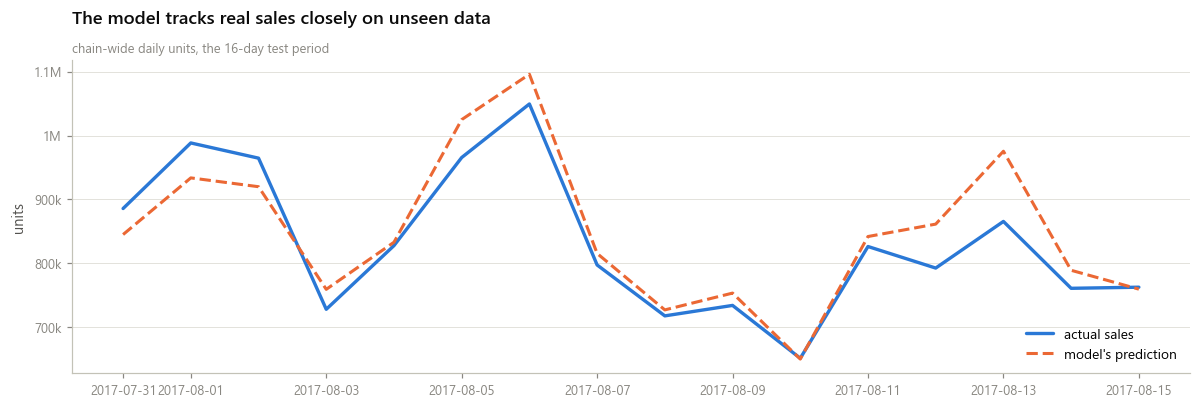

In [13]:
va_info = pd.DataFrame({"date": pd.to_datetime(VALID_START) + pd.to_timedelta(DAY_OF - 1, "D"),
                        "family": va_family, "actual": y_va, "pred": p_va})
actual_by_date = va_info.groupby("date").actual.sum()
pred_by_date = va_info.groupby("date").pred.sum()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(actual_by_date.index, actual_by_date.values, color=CAT[0], lw=2.2, label="actual sales")
ax.plot(pred_by_date.index, pred_by_date.values, color=CAT[1], lw=2, ls="--",
       label="model's prediction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "The model tracks real sales closely on unseen data",
      "chain-wide daily units, the 16-day test period", ylabel="units")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

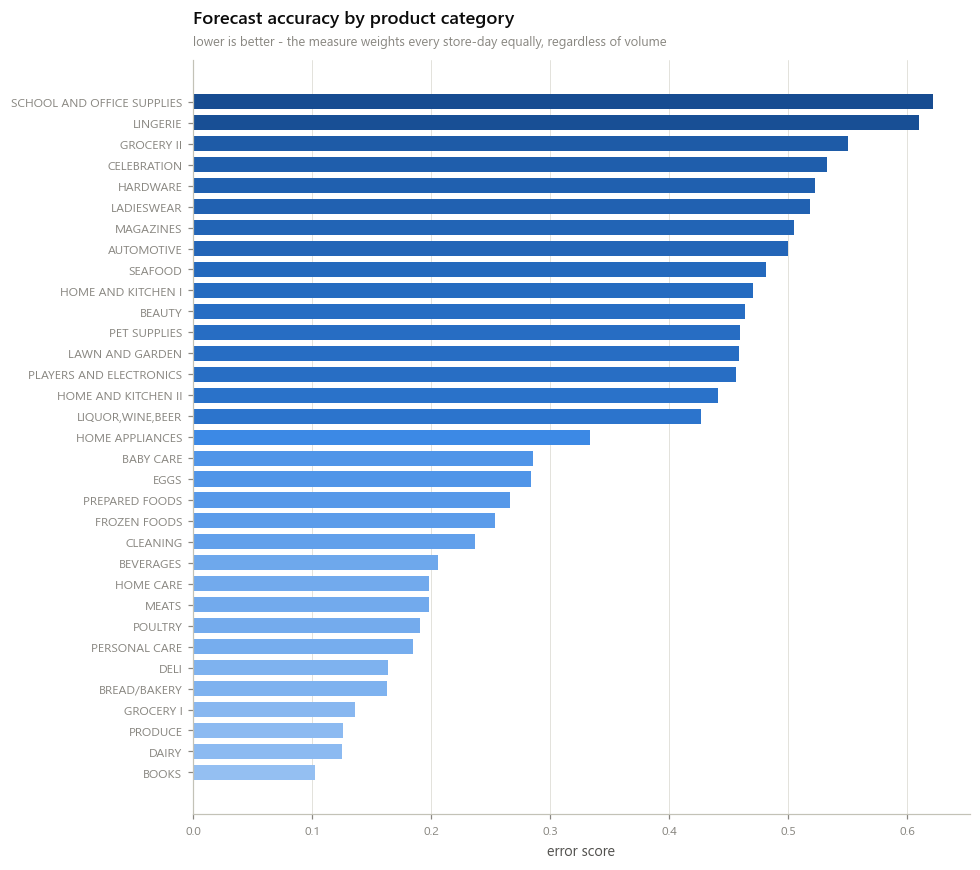

Most accurate categories: BOOKS, DAIRY, PRODUCE
Least accurate categories: GROCERY II, LINGERIE, SCHOOL AND OFFICE SUPPLIES


In [14]:
sq_err = (np.log1p(p_va) - np.log1p(y_va)) ** 2
fam_rmsle = (pd.DataFrame({"family": va_family, "sq_err": sq_err})
            .groupby("family", observed=True).sq_err.mean().pow(0.5).sort_values())

fig, ax = plt.subplots(figsize=(9, 8))
norm = (fam_rmsle - fam_rmsle.min()) / (fam_rmsle.max() - fam_rmsle.min())
ax.barh(fam_rmsle.index.astype(str), fam_rmsle.values,
       color=SEQ(0.2 + 0.65 * norm.values), height=0.72)
ax.tick_params(labelsize=8)
finish(ax, "Forecast accuracy by product category",
      "lower is better - the measure weights every store-day equally, regardless of volume",
      xlabel="error score", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

print("Most accurate categories:", ", ".join(fam_rmsle.head(3).index.astype(str)))
print("Least accurate categories:", ", ".join(fam_rmsle.tail(3).index.astype(str)))

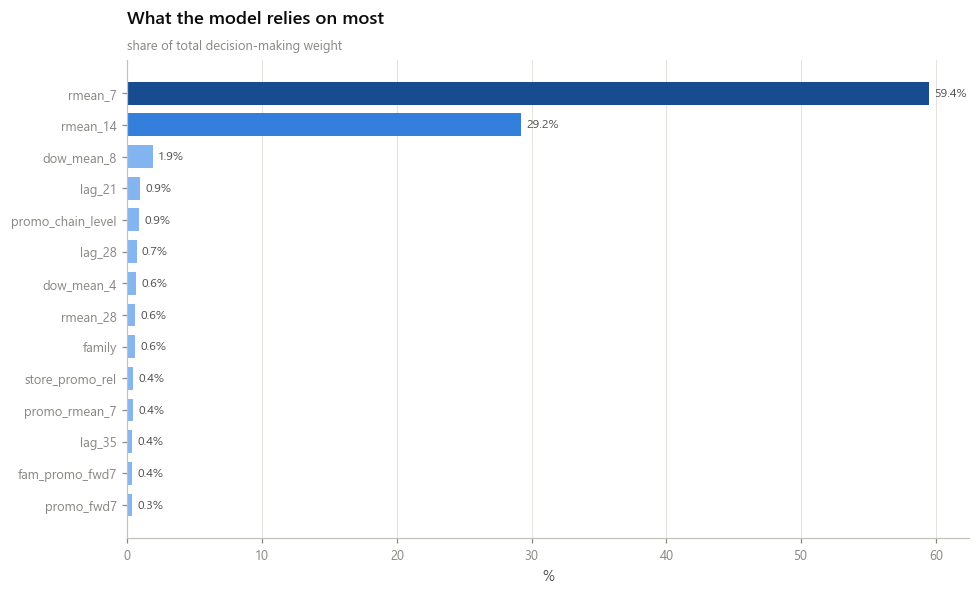

Recent sales history alone accounts for 95% of the model's decisions. Promotions, holidays, and store/category identity make up the rest.


In [15]:
imp = (pd.DataFrame({"feature": ref_model.feature_name(),
                     "gain": ref_model.feature_importance("gain")})
       .assign(share=lambda x: x.gain / x.gain.sum())
       .sort_values("gain", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
top = imp.head(14).iloc[::-1]
norm = (top.share - top.share.min()) / (top.share.max() - top.share.min())
ax.barh(top.feature, top.share * 100, color=SEQ(0.25 + 0.6 * norm.values), height=0.72)
for y_, v in enumerate(top.share * 100):
    ax.text(v + 0.4, y_, f"{v:.1f}%", va="center", fontsize=8, color=SECOND)
finish(ax, "What the model relies on most", "share of total decision-making weight",
      xlabel="%", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

recent = imp.feature.str.startswith(("lag_", "rmean_", "dow_mean"))
print(f"Recent sales history alone accounts for {imp.loc[recent, 'share'].sum():.0%} of the "
      f"model's decisions. Promotions, holidays, and store/category identity make up the rest.")

---
## The 16-Day Forecast

Every model — the four direct ones and the recursive one — is retrained on **all** available
history, including the two weeks just used for testing, before producing the final forecast.
No useful data is left on the table.

The two forecasters are then combined in the proportion described in *A Second Opinion* — 70/30
for most categories, adjusted for the three that consistently behave differently — and the
discontinued-line rule is applied last.

In [16]:
test_log, te_key = {}, None
for min_lag in MIN_LAGS:
    t = time.time()
    d, cols = build_design(min_lag)
    eq_row = d.date.isin(eq_dates)
    full_tr = (d.date <= TRAIN_END) & d.target.notna() & ~eq_row
    te_m = d.date > TRAIN_END
    dfull = lgb.Dataset(d.loc[full_tr, cols], d.loc[full_tr, "target"],
                        categorical_feature=CATS, free_raw_data=False)
    logs = []
    for i in range(len(SEED_CFG)):
        mi = lgb.train(seed_params(i), dfull, num_boost_round=best_rounds[min_lag])
        logs.append(mi.predict(d.loc[te_m, cols]))
        del mi; gc.collect()
    test_log[min_lag] = np.mean(logs, axis=0)
    if te_key is None:
        te_key = d.loc[te_m, ["date", "store_nbr", "family"]].copy()
    print(f"  model for days needing {min_lag:>2}-day-old sales: refit ({time.time()-t:.0f}s)")
    del d, dfull, logs; gc.collect()

te_day = ((te_key.date.to_numpy() - np.datetime64(TRAIN_END)) / np.timedelta64(1, "D")).astype(int)
direct_log = np.empty(len(te_key))
for day, ml in ASSEMBLY.items():
    direct_log[te_day == day] = test_log[ml][te_day == day]

# The second forecaster, refit on the full history and rolled forward over the 16 days.
te_dates = pd.date_range(TRAIN_END + pd.Timedelta(days=1), test.date.max())
t = time.time()
rec_test = pd.DataFrame(index=te_dates, columns=SERIES, dtype="float32")
for fam in FAMILIES:
    p, cols = run_family(fam, TRAIN_END, te_dates)
    rec_test[cols] = p
recursive_log = rec_test.to_numpy().ravel()
print(f"  second forecaster refit and rolled forward ({time.time()-t:.0f}s)")

# The two forecasts must line up row for row before they can be averaged. Checking this
# rather than trusting it: averaging two misaligned tables would produce plausible-looking
# numbers and a silently wrong forecast.
exp_store = np.tile(SERIES.get_level_values(0).to_numpy(), len(te_dates))
exp_fam = np.tile(SERIES.get_level_values(1).to_numpy(), len(te_dates))
assert (te_key.store_nbr.to_numpy() == exp_store).all(), "row order mismatch (store)"
assert (te_key.family.astype(str).to_numpy() == exp_fam).all(), "row order mismatch (category)"
assert abs(direct_log.mean() - recursive_log.mean()) < 1.0, \
    "the two forecasters disagree on scale -- one of them did not train properly"
print("  the two forecasts are aligned and on the same scale")

te_fam = te_key.family.astype(str).to_numpy()
w_row_te = np.full(len(te_key), BLEND_W)
for fam, w in FAMILY_WEIGHT.items():
    w_row_te[te_fam == fam] = w
final_log = w_row_te * direct_log + (1 - w_row_te) * recursive_log
pred = np.clip(np.expm1(final_log), 0, None)

  model for days needing  1-day-old sales: refit (483s)


  model for days needing  2-day-old sales: refit (715s)


  model for days needing  4-day-old sales: refit (1033s)


  model for days needing 16-day-old sales: refit (1391s)


C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

  second forecaster refit and rolled forward (70s)
  the two forecasts are aligned and on the same scale


C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: Futur

In [17]:
# Product lines with no sales at all in the past year are forecast as exactly zero.
# Judged on the raw sales file, which is the most defensible source for a "did this ever
# sell" question.
cutoff = TRAIN_END - pd.Timedelta(days=DORMANT_DAYS)
recent_total = (train[train.date > cutoff]
                .groupby(["store_nbr", "family"], observed=True).sales.sum())
dead = {(s, str(f)) for (s, f), v in recent_total.items() if v == 0}
all_keys = {(s, str(f)) for s, f in zip(test.store_nbr, test.family.astype(str))}
dead |= all_keys - {(s, str(f)) for s, f in recent_total.index}

keys = list(zip(te_key.store_nbr.to_numpy(), te_key.family.astype(str).to_numpy()))
dormant = np.array([k in dead for k in keys])
leaked = pred[dormant]
print(f"discontinued lines (no sales in {DORMANT_DAYS} days): {len(dead)} store-category "
      f"combinations, {dormant.sum():,} forecast rows ({dormant.mean():.1%})")
print(f"the models were forecasting {leaked.sum():,.0f} units across them "
      f"(on average {leaked.mean():.2f} per row) -- {leaked.sum()/pred.sum():.3%} of all volume")
pred = pred.copy()
pred[dormant] = 0.0

out = te_key.copy()
out["sales"] = pred
out["family"] = out.family.astype(str)

key = test.assign(family=test.family.astype(str))[["id", "date", "store_nbr", "family"]]
submission = key.merge(out, on=["date", "store_nbr", "family"], how="left")

assert len(submission) == len(test)
assert submission.sales.notna().all()
assert (submission.sales >= 0).all()
assert submission.id.equals(test.id)

submission[["id", "sales"]].to_csv(OUT / "sales_forecast.csv", index=False)
print(f"\nforecast written -> {(OUT / 'sales_forecast.csv').resolve()}")
print(f"total forecast units, 16 days: {submission.sales.sum():,.0f}")

discontinued lines (no sales in 365 days): 65 store-category combinations, 1,040 forecast rows (3.6%)
the models were forecasting 495 units across them (on average 0.48 per row) -- 0.004% of all volume



forecast written -> G:\Meu Drive\_Portifolio\Store Sales - Time Series Forecasting\submissions\stakeholder\sales_forecast.csv
total forecast units, 16 days: 12,636,219


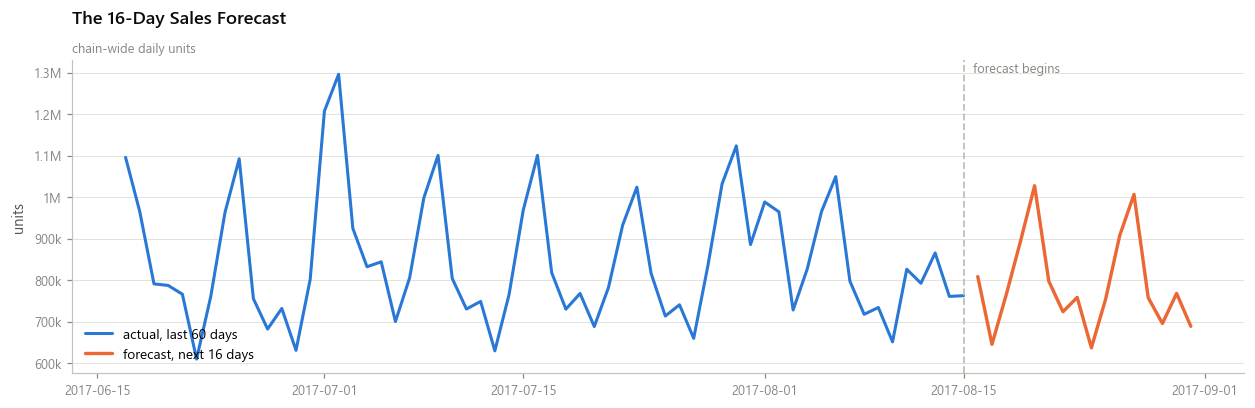

recent actual pace : 832,449 units/day
forecast pace      : 789,764 units/day  (-5.1% vs. the last 16 days)

Worth checking on this chart: the forecast should join the history smoothly. Because
different models produce days 1-2, 3-4 and 5-16, a visible step at those boundaries
would signal a problem -- the weekly rhythm should be the only visible pattern.
largest day-to-day change in the forecast: 25% (the weekly cycle alone moves sales about this much)


In [18]:
hist = train[train.date > TRAIN_END - pd.Timedelta(days=60)].groupby("date").sales.sum()
fut = submission.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(11.5, 3.8))
ax.plot(hist.index, hist.values, color=CAT[0], lw=2, label="actual, last 60 days")
ax.plot(fut.index, fut.values, color=CAT[1], lw=2.2, label="forecast, next 16 days")
ax.axvline(TRAIN_END, color=AXIS_LINE, lw=1.2, ls="--")
ax.annotate("forecast begins", xy=(TRAIN_END, 0.96), xycoords=("data", "axes fraction"),
           xytext=(6, 0), textcoords="offset points", color=MUTED, fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "The 16-Day Sales Forecast", "chain-wide daily units", ylabel="units")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

print(f"recent actual pace : {hist.tail(16).mean():,.0f} units/day")
print(f"forecast pace      : {fut.mean():,.0f} units/day  "
      f"({fut.mean()/hist.tail(16).mean()-1:+.1%} vs. the last 16 days)")
print()
print("Worth checking on this chart: the forecast should join the history smoothly. Because")
print("different models produce days 1-2, 3-4 and 5-16, a visible step at those boundaries")
print("would signal a problem -- the weekly rhythm should be the only visible pattern.")
step = fut.pct_change().abs().max()
print(f"largest day-to-day change in the forecast: {step:.0%} "
      f"(the weekly cycle alone moves sales about this much)")

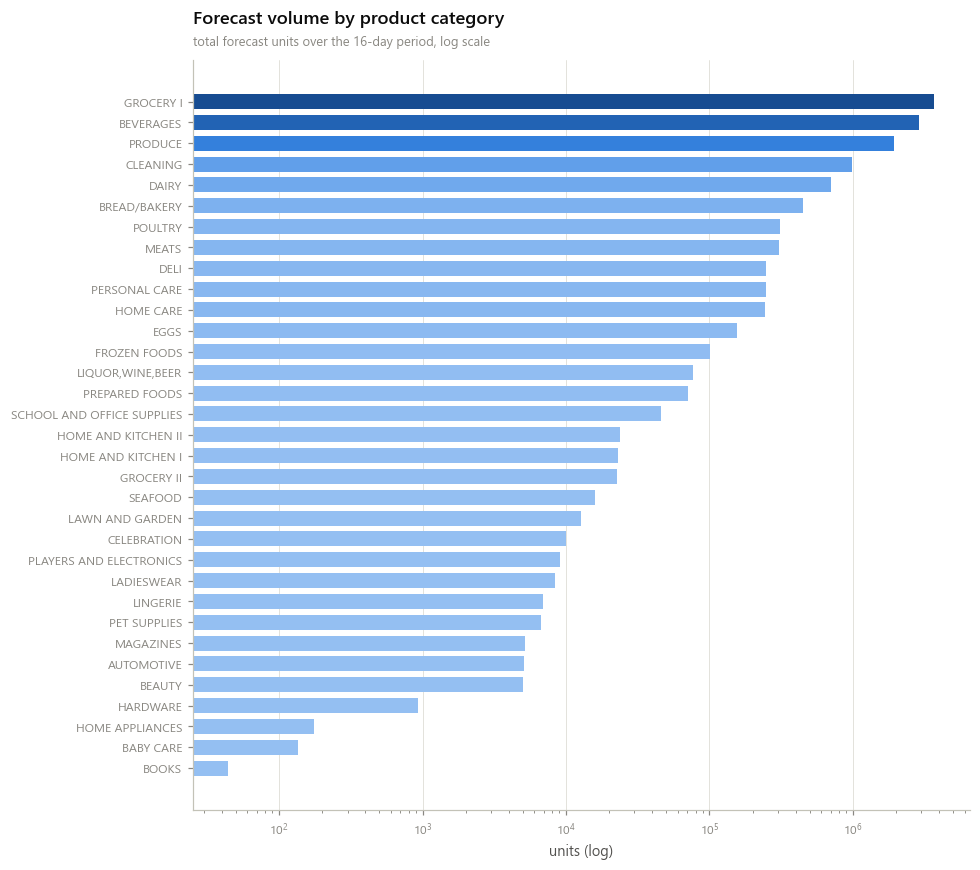

In [19]:
fam_forecast = submission.groupby("family", observed=True).sales.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top = fam_forecast.iloc[::-1]
norm = (top - top.min()) / (top.max() - top.min())
ax.barh(top.index.astype(str), top.values, color=SEQ(0.2 + 0.65 * norm.values), height=0.72)
ax.set_xscale("log")
ax.tick_params(labelsize=8)
finish(ax, "Forecast volume by product category",
      "total forecast units over the 16-day period, log scale", xlabel="units (log)",
      ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

---
## Where to Pay Extra Attention

Three things are worth flagging for anyone acting on this forecast.

**A category in the middle of its annual surge.** `SCHOOL AND OFFICE SUPPLIES` consistently
scores among the least accurate categories in testing, and this forecast period sits in the
middle of Ecuador's back-to-school season. In 2017 that surge arrived unusually early and
unusually large — sales rose more than twenty-fold from early July to a peak in the first week
of August, then began easing. A model learns this shape from only two previous years, neither
of which peaked at the same point in the calendar, so the forecast for this category carries
more uncertainty than any other. It is the single category most worth a manual sanity check
before ordering against it.

**A one-off local holiday inside the forecast window.** Exactly one holiday falls in these
16 days: **Fundacion de Ambato**, a city-specific holiday on 2017-08-24 that only affects the
two stores located in Ambato. Historically this holiday's effect on sales has been
inconsistent — three of the last four years showed little change, one showed a sharp drop —
so there isn't enough history to say confidently which way it will go this time. The chart
below shows what the model currently predicts for those two stores.

**Discontinued lines are now hard zeros.** The 65 store-category combinations described in
*Products That No Longer Sell* are forecast as exactly zero. If any of them is being
deliberately restocked, that decision is invisible to the forecast and needs to be handled
outside it.

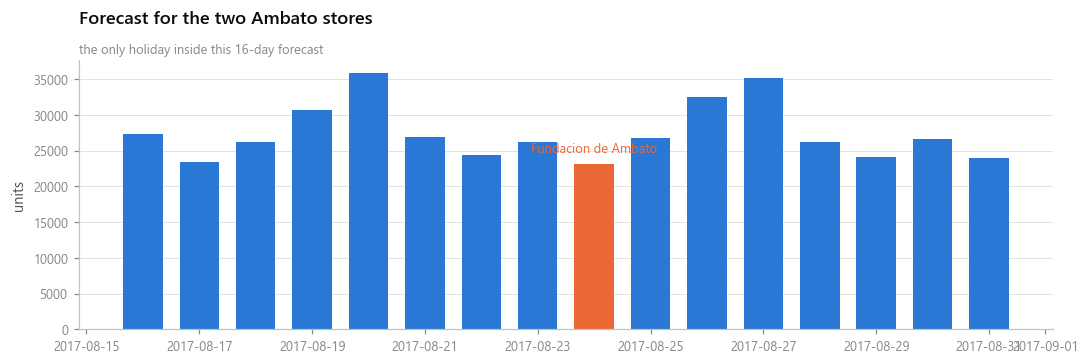

forecast for the holiday itself       : 23,101 units
forecast for other Thursdays in-window: 23,738 units


In [20]:
amb_stores = sorted(stores.loc[stores.city == "Ambato", "store_nbr"])
AMB_DAY = pd.Timestamp("2017-08-24")
amb = submission[submission.store_nbr.isin(amb_stores)].copy()
per_day = amb.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(10, 3.4))
cols_ = [CAT[1] if d == AMB_DAY else CAT[0] for d in per_day.index]
ax.bar(per_day.index, per_day.values, color=cols_, width=0.7)
ax.annotate("Fundacion de Ambato", xy=(AMB_DAY, per_day.loc[AMB_DAY]), xytext=(0, 8),
           textcoords="offset points", ha="center", color=CAT[1], fontsize=8.5)
finish(ax, "Forecast for the two Ambato stores",
      "the only holiday inside this 16-day forecast", ylabel="units")
fig.tight_layout(); plt.show()

same_dow = per_day[(per_day.index.dayofweek == AMB_DAY.dayofweek) & (per_day.index != AMB_DAY)]
print(f"forecast for the holiday itself       : {per_day.loc[AMB_DAY]:,.0f} units")
print(f"forecast for other Thursdays in-window: {same_dow.mean():,.0f} units")

---
## How to Use This Forecast

- **Trust the chain-wide and category-level totals most.** They are backed by four and a
  half years of history and consistently score well in testing.
- **`SCHOOL AND OFFICE SUPPLIES` already gets extra weight toward the faster-adapting
  forecaster** for exactly this reason, but it still sits on its annual surge with only two
  comparable years to learn from, and 2017's surge behaved unlike either — a buffer here is
  still worth adding.
- **Treat the first two forecast days as the most reliable and the last as the least.** This
  is inherent to forecasting, and it is why separate models are used for the near days: they
  can see recent sales the later days cannot.
- **The Ambato stores' forecast for 2017-08-24** should be treated as an estimate with wide
  error bars, given the thin and inconsistent history behind it.
- **Refresh this forecast** as new sales data becomes available — a two-week-ahead forecast
  naturally gets more reliable the closer the forecast origin is to the day being predicted,
  and the four-model design means fresh data improves the near days immediately.

### Methodology summary

**The direct forecaster.** Four gradient-boosted tree models (LightGBM), each trained on daily
sales from 2015 onward and each restricted to the sales history genuinely available for the
forecast days it serves: day 1, day 2, days 3–4, and days 5–16. Inputs are recent sales trends,
promotional activity (including known upcoming promotions), the corrected holiday calendar,
paydays, and store/category identity. Five variants of each are averaged to reduce noise.

**The recursive forecaster.** One model per product category, trained to predict a single day
from the previous 63 and then run forward sixteen times, each prediction feeding the next. Each
store-series is rescaled to a common range so one small model can serve 54 stores of very
different sizes.

**Combination.** The two are averaged 70/30 in the same logarithmic scale the accuracy measure
uses, except for three categories (`SCHOOL AND OFFICE SUPPLIES`, `HOME APPLIANCES`,
`AUTOMOTIVE`) where a different split was found to help consistently across three separate
historical periods. Product lines with no sales in the preceding year are then forced to
exactly zero.

**Validation.** A 16-day period held out from training, evaluated with the same measure the
forecast will ultimately be judged on. Training on the older years was tested and is
deliberately excluded: forecasts get *worse* when 2013–2014 are included, because the chain has
changed enough that stale years dilute recent ones.